# Question 1

### Library import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

### EDA

In [18]:
df = pd.read_csv("sku_data.csv", index_col = 0)

In [19]:
df.shape

(2279, 7)

In [20]:
df.head()

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
ID,,,,,,,
1,0.058,547,9,2441.0,105.60,1.56,1920
2,0.954,547,0,0.0,207.68,1.00,384
3,2.385,547,12,23.0,165.78,1.02,108
4,5.100,547,0,0.0,221.04,1.05,72
5,0.000,547,0,0.0,0.00,0.00,0


In [21]:
df.dtypes

Unitprice          float64
Expire date          int64
Outbound number      int64
Total outbound     float64
Pal grossweight    float64
Pal height         float64
Units per pal        int64
dtype: object

In [22]:
df.isnull().sum()

Unitprice          0
Expire date        0
Outbound number    0
Total outbound     0
Pal grossweight    0
Pal height         0
Units per pal      0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(357)

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unitprice,2279.0,4.269402,14.449000,0.0,0.0,1.2938,4.545,518.592
Expire date,2279.0,410.371654,240.875419,0.0,365.0,547.0000,547.000,734.000
Outbound number,2279.0,235.976305,700.230685,0.0,0.0,1.0000,45.000,6325.000
Total outbound,2279.0,731.701053,2146.029848,0.0,0.0,3.0000,419.500,26411.000
Pal grossweight,2279.0,192.939582,164.616813,0.0,60.0,167.6800,277.560,907.200
Pal height,2279.0,0.672798,0.552117,0.0,0.0,0.8400,1.020,2.160
Units per pal,2279.0,755.563405,6278.437915,0.0,32.0,108.0000,384.000,200000.000


In [25]:
zero_counts = (df == 0).sum()
zero_counts

Unitprice          710
Expire date        529
Outbound number    979
Total outbound     979
Pal grossweight    371
Pal height         787
Units per pal      295
dtype: int64

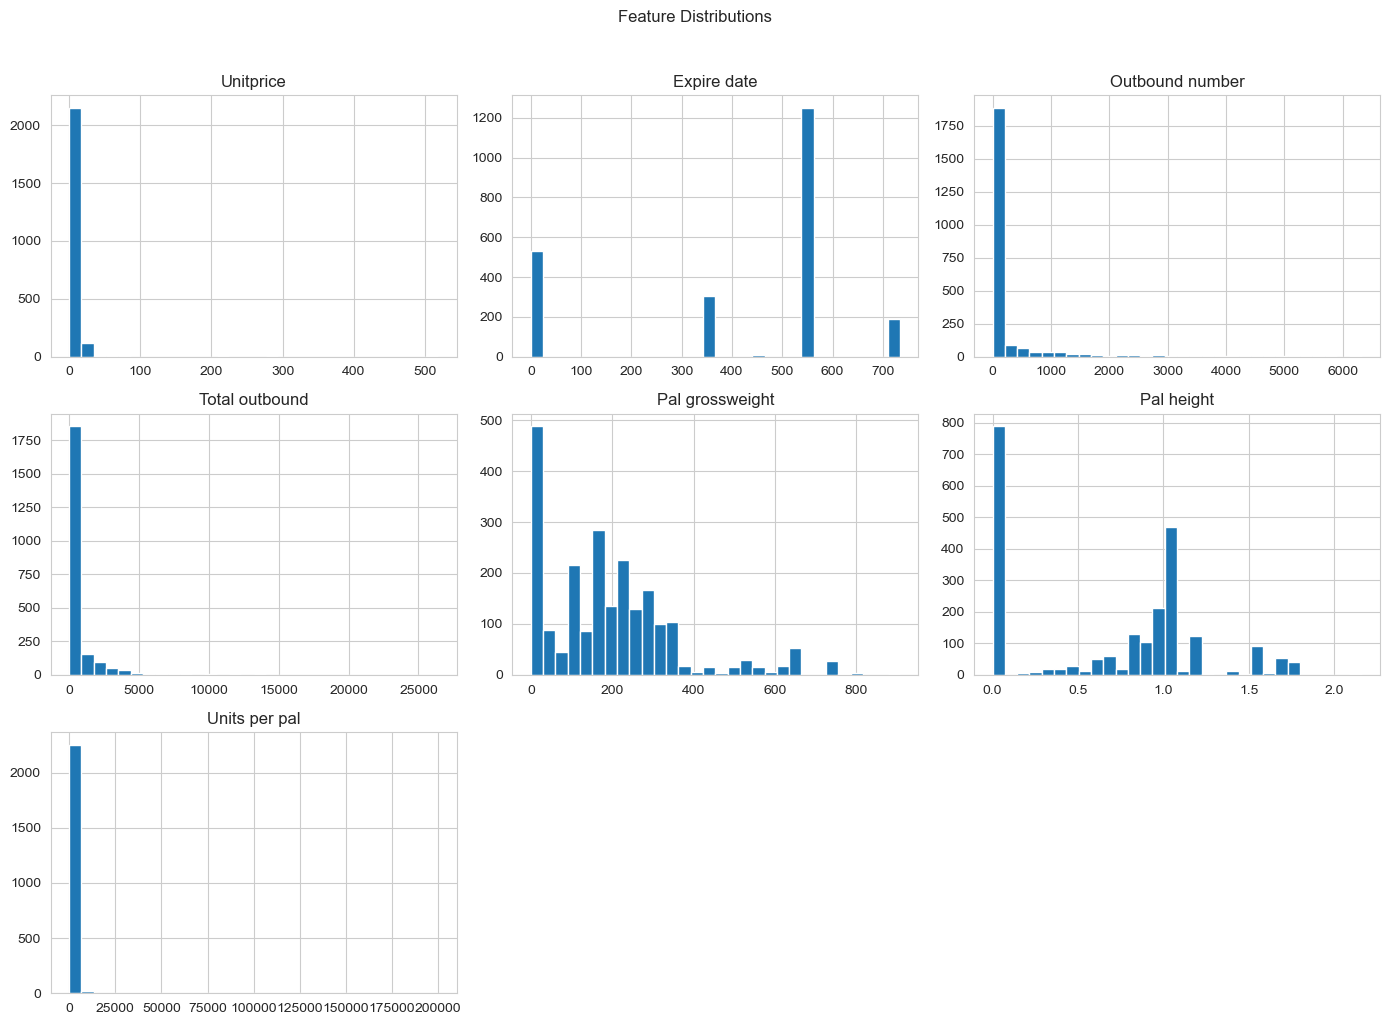

In [26]:
df.hist(bins=30, figsize=(14, 10))
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

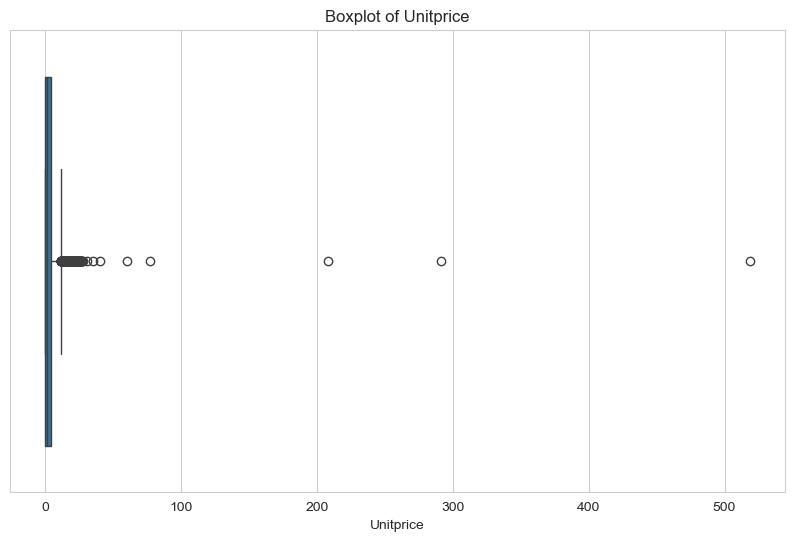

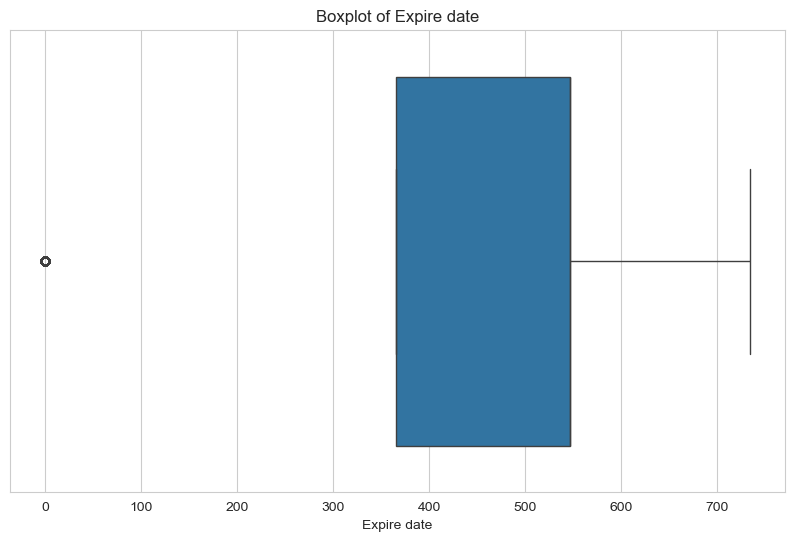

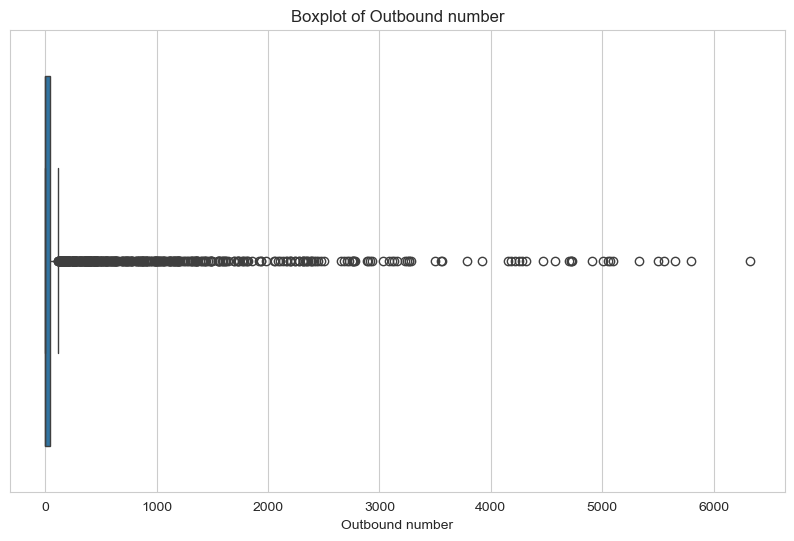

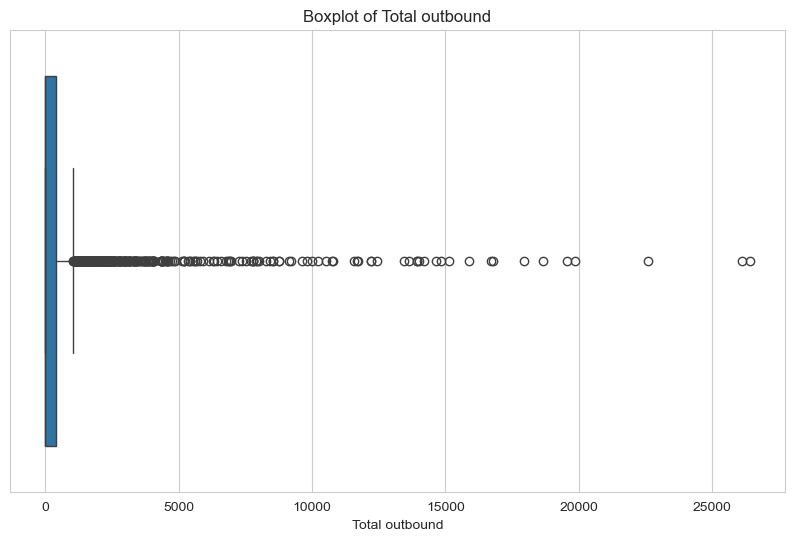

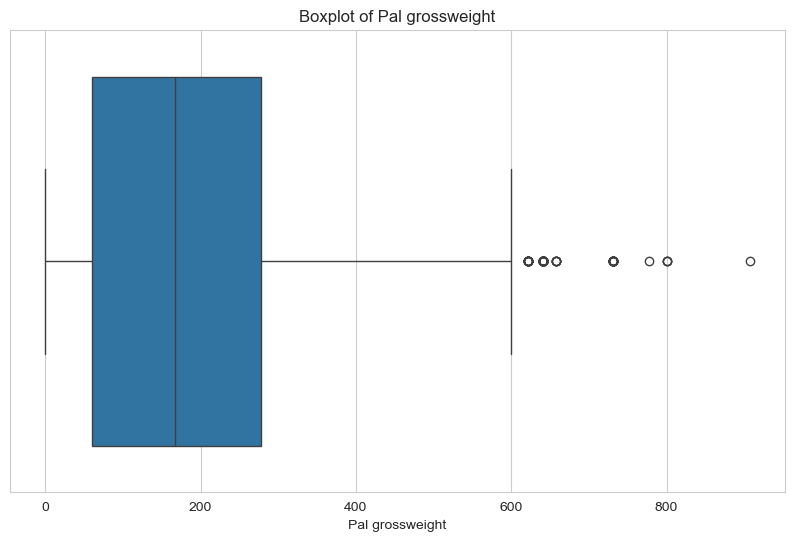

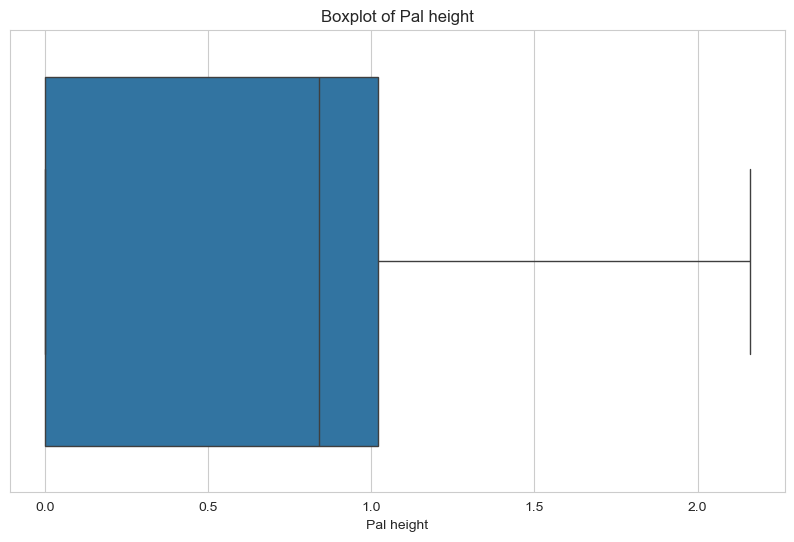

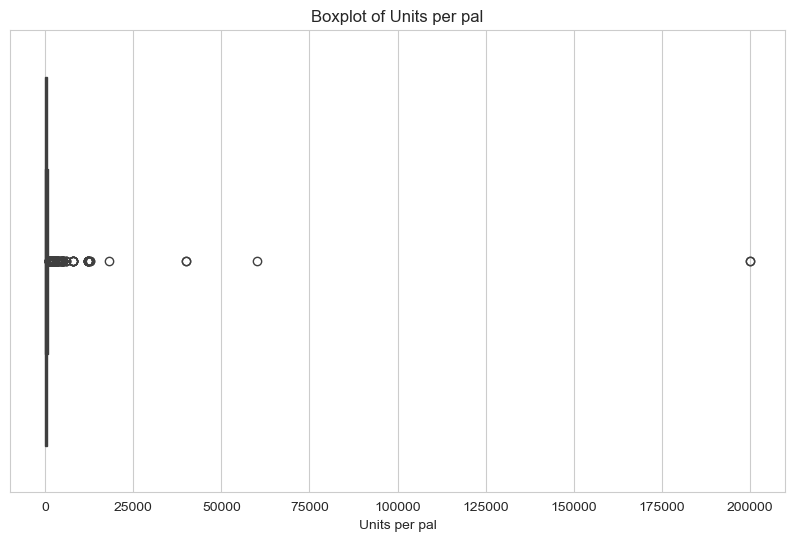

In [27]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [28]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
corr

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
Unitprice,1.000000,-0.038071,-0.012483,-0.039907,0.192024,0.095484,-0.031315
Expire date,-0.038071,1.000000,0.209473,0.160389,0.261866,0.254724,-0.097641
Outbound number,-0.012483,0.209473,1.000000,0.864548,0.113197,0.192916,-0.025278
Total outbound,-0.039907,0.160389,0.864548,1.000000,0.047781,0.169287,0.006232
Pal grossweight,0.192024,0.261866,0.113197,0.047781,1.000000,0.467171,0.086066
Pal height,0.095484,0.254724,0.192916,0.169287,0.467171,1.000000,-0.048170
Units per pal,-0.031315,-0.097641,-0.025278,0.006232,0.086066,-0.048170,1.000000


<Figure size 1000x800 with 0 Axes>

## Clustering

In [30]:
X = df.copy()

In [31]:
X_log = np.log1p(X)
X_log.head()

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
ID,,,,,,,
1,0.056380,6.306275,2.302585,7.800573,4.669084,0.940007,7.560601
2,0.669879,6.306275,0.000000,0.000000,5.340802,0.693147,5.953243
3,1.219354,6.306275,2.564949,3.178054,5.116676,0.703098,4.691348
4,1.808289,6.306275,0.000000,0.000000,5.402858,0.717840,4.290459
5,0.000000,6.306275,0.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled

array([[-0.9302019 ,  0.56396574,  0.08772294, ...,  0.16987816,
         1.37076761,  1.35376031],
       [-0.33071621,  0.56396574, -0.80399566, ...,  0.49210273,
         0.6734121 ,  0.66248527],
       [ 0.20620892,  0.56396574,  0.18932835, ...,  0.38458889,
         0.70152081,  0.11978294],
       ...,
       [-0.98529449, -1.81526527, -0.80399566, ..., -0.30806479,
        -1.28466071, -1.20565152],
       [-0.98529449, -1.81526527, -0.53556162, ..., -0.50494961,
        -1.28466071, -1.30161869],
       [-0.98529449,  0.56396574,  0.87822321, ...,  0.16987816,
        -1.28466071,  1.35376031]], shape=(2279, 7))

In [35]:
inertia = []
k_values = range(2, 11)

In [36]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

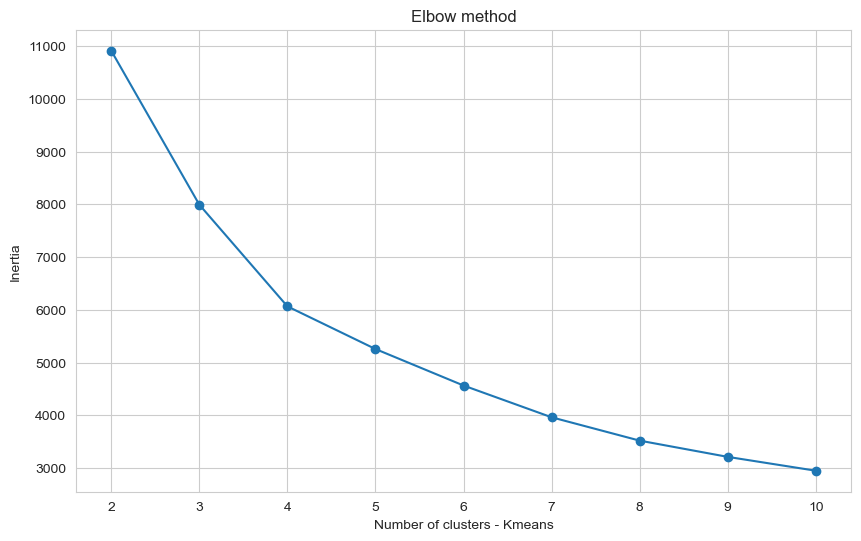

In [37]:
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow method")
plt.xlabel("Number of clusters - Kmeans")
plt.ylabel("Inertia")
plt.show()

In [38]:
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

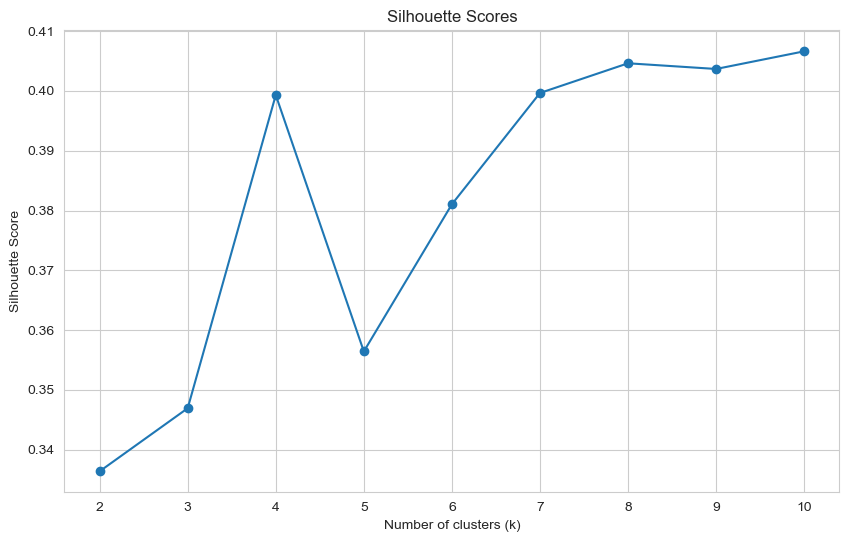

In [39]:
plt.plot(k_values, sil_scores, marker="o")
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [40]:
for k, score in zip(k_values, sil_scores):
    print(f"k = {k}, silhouette score = {score:.4f}")

k = 2, silhouette score = 0.3364
k = 3, silhouette score = 0.3469
k = 4, silhouette score = 0.3993
k = 5, silhouette score = 0.3564
k = 6, silhouette score = 0.3811
k = 7, silhouette score = 0.3997
k = 8, silhouette score = 0.4046
k = 9, silhouette score = 0.4037
k = 10, silhouette score = 0.4066


In [41]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

C:\Users\alnur\Coding\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [46]:
print(df[["Cluster"]].head())

print("\nCluster counts:")
print(df["Cluster"].value_counts())

    Cluster
ID         
1         2
2         0
3         0
4         0
5         1

Cluster counts:
Cluster
0    1070
2     713
1     496
Name: count, dtype: int64


In [47]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]

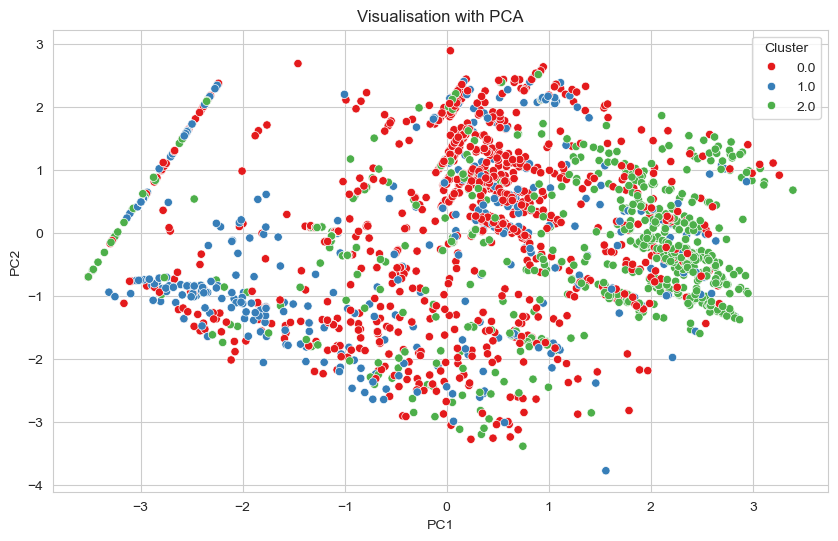

Explained variance ratio:
[0.4325001  0.20303682]
Total explained variance: 0.635536923909193


In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set1")
plt.title("Visualisation with PCA")
plt.show()

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

In [52]:
cluster_profile = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_profile)

         Unitprice  Expire date  Outbound number  Total outbound  \
Cluster                                                            
0         4.971547   423.654206         2.204673       19.036449   
1         2.613437   272.836694         1.000000        9.764113   
2         4.367668   486.115007       750.259467     2303.414727   

         Pal grossweight  Pal height  Units per pal  
Cluster                                              
0             247.811187    0.785599     871.643925  
1               7.614089    0.072560      52.844758  
2             239.515778    0.921073    1070.208976  
